# Q5: Pattern Analysis

**Phase 6:** Pattern Analysis & Advanced Visualization  
**Points: 6 points**

**Focus:** Identify trends over time, analyze seasonal patterns, create correlation analysis.

**Lecture Reference:** Lecture 11, Notebook 3 ([`11/demo/03_pattern_analysis_modeling_prep.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/03_pattern_analysis_modeling_prep.ipynb)), Phase 6. Also see Lecture 08 (groupby) and Lecture 07 (visualization).

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load feature-engineered data from Q4
#df = pd.read_csv('output/q4_features.csv', parse_dates=['Measurement Timestamp'], index_col='Measurement Timestamp')
# Or if you saved without index:
df = pd.read_csv('output/q4_rolling_features.csv')
df['Measurement Timestamp'] = pd.to_datetime(df['Measurement Timestamp'])
df = df.set_index('Measurement Timestamp')
print(f"Loaded {len(df):,} records with features")

Loaded 120,411 records with features


## Key Variable Correlation

In [2]:
# 1. `output/q5_correlations.csv`

# Begin chunk
print('Beginning analysis of the correlations between key variables ...')

# Key Variables 
key_variables = [
    'Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Wind Speed', 'Barometric Pressure', 
    'Solar Radiation', 'temp_difference', 'temp_humidity', 'wind_solar', 'wind_ratio'
    ]

# Correlation
corr_matrix = df[key_variables].corr()

# Output q5_correlations.csv
corr_matrix.to_csv('output/q5_correlations.csv', header = True, index = True)

# End chunk
print('Analysis of the key variables complete! Results saved at: output/q5_correlations.csv')

Beginning analysis of the correlations between key variables ...
Analysis of the key variables complete! Results saved at: output/q5_correlations.csv


## Patterns of Key Variables

Creating visualizations showing seasonality/trends of key variables ...


/var/folders/q2/425x2zhd1b3f3hnjp4v223880000gn/T/ipykernel_92242/105338309.py:28: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_barometric_pressure = df['Barometric Pressure'].resample('A').sum()


Creation of visualizations complete! Results saved at: output/q5_patterns.png


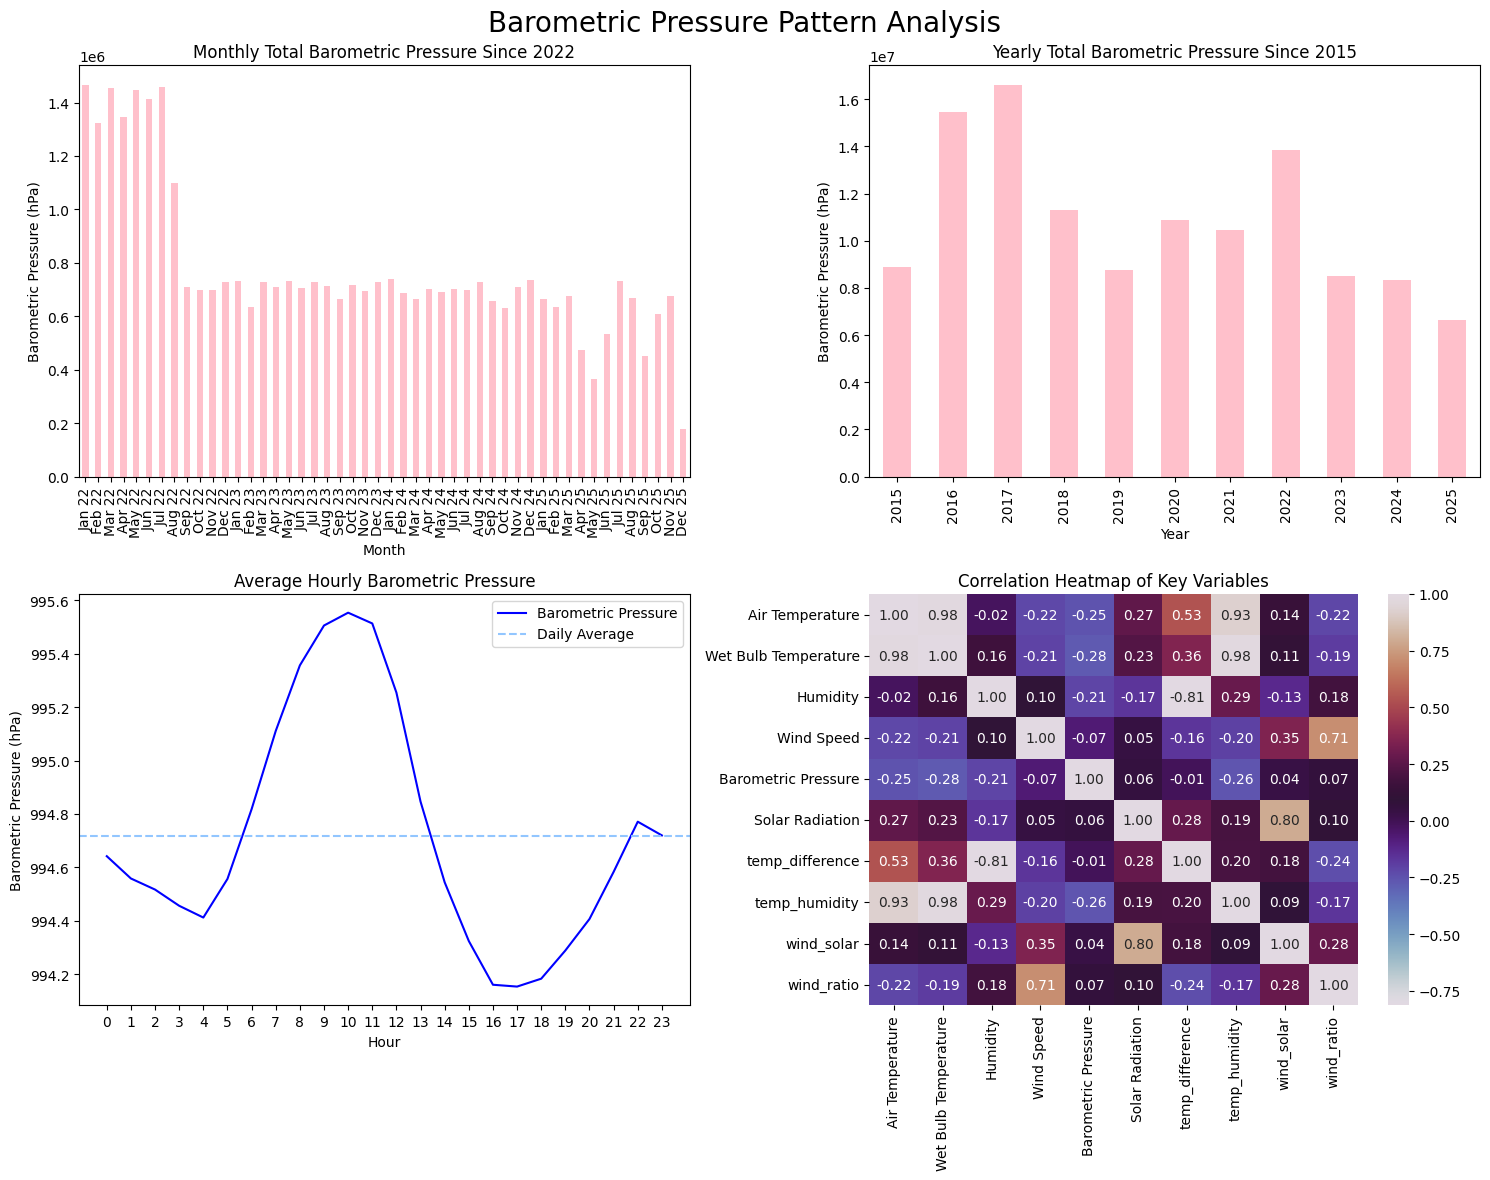

In [3]:
# 2. `output/q5_patterns.png`

# Begin chunk
print('Creating visualizations showing seasonality/trends of key variables ...')

# Plot Style
plt.style.use('seaborn-v0_8-pastel')

# Set-up Layout
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 12))

# Look at 2022-2025
df_2022 = df[df.index.year >= 2022]
monthly_barometric_pressure = df_2022['Barometric Pressure'].resample('ME').sum()

# Monthly Barometric Pressure Plot 1
monthly_barometric_pressure.plot(
    kind = 'bar',
    ax = axes[0, 0],
    xlabel = 'Month',
    ylabel = 'Barometric Pressure (hPa)',
    title = 'Monthly Total Barometric Pressure Since 2022',
    color = 'Pink'
)
axes[0, 0].set_xticklabels(date.strftime('%b %y') for date in monthly_barometric_pressure.index)

# Yearly Barometric Pressure Plot 2
yearly_barometric_pressure = df['Barometric Pressure'].resample('A').sum()
yearly_barometric_pressure.plot(
    kind = 'bar',
    ax = axes[0, 1],
    xlabel = 'Year',
    ylabel = 'Barometric Pressure (hPa)',
    title = 'Yearly Total Barometric Pressure Since 2015',
    color = 'Pink'
)
axes[0, 1].set_xticklabels(date.strftime('%Y') for date in yearly_barometric_pressure.index)

# Hourly Average Barometric Pressure Plot 3
hour_pattern = df.groupby(df.index.hour)['Barometric Pressure'].mean()
hour_pattern.plot(
    kind = 'line',
    ax = axes[1, 0],
    xlabel = 'Hour',
    ylabel = 'Barometric Pressure (hPa)',
    title = 'Average Hourly Barometric Pressure',
    color = 'Blue'
)
axes[1, 0].axhline(y = df['Barometric Pressure'].mean(), linestyle = '--', label = 'Daily Average')
axes[1, 0].legend()
axes[1, 0].set_xticks(range(24))

# Heatmap Plot 4
sns.heatmap(
    corr_matrix, 
    ax = axes[1, 1],
    annot = True,
    fmt = '.2f',
    cmap = 'twilight'
    )
axes[1, 1].set_title('Correlation Heatmap of Key Variables')
fig.suptitle('Barometric Pressure Pattern Analysis', fontsize = 20)

# Output q5_patterns.png
plt.tight_layout()
plt.savefig('output/q5_patterns.png', dpi = 300, bbox_inches = 'tight')

# End chunk
print('Creation of visualizations complete! Results saved at: output/q5_patterns.png')


## Trend Analysis

In [4]:
# 3. `output/q5_trend_summary.txt`

# Begin chunk
print('Creating a text file on our analysis of the key patterns from the above visualizations')

# Create text file
with open('output/q5_trend_summary.txt', 'w') as f:
    f.write('KEY PATTERNS IDENTIFIED\n')
    f.write('======================\n\n')

    f.write('TEMPORAL TRENDS:\n')
    f.write('- Barometric pressure shows declining trend from 2015-2025\n')
    f.write('- Unusual spike and subsequent decline from 2021-2023. Grounds for further research\n')
    f.write('- The last year with complete data, 2024, shows the lowest total yearly pressure (~8M hPa)\n\n')

    f.write('DAILY PATTERNS:\n')
    f.write('- Barometric pressure shows expected cyclic trend (peaks 10-12 PM, craters 4-6 PM)\n')
    f.write('- Barometric pressure remains roughly consistent throughout the day (bounds [994,996])\n')
    f.write('- Average hourly barometric pressure is 994.7 hPa\n\n')

    f.write('CORRELATIONS:\n')
    f.write('- Barometric pressure shows low correlation with all other features (maximum absolute correlation: 0.28)\n')
    f.write('- Air temperature and Wet bulb temperature nearly perfectly correlated: 0.98\n')
    f.write('- Wind speed shows low correlation (< |0.22|) with all other non-derived features')

# End chunk
print('Creation of the text file complete! Results saved at: output/q5_trend_summary.txt')

Creating a text file on our analysis of the key patterns from the above visualizations
Creation of the text file complete! Results saved at: output/q5_trend_summary.txt


---

## Objective

Identify trends over time, analyze seasonal patterns, and create correlation analysis.

**Time Series Note:** Time series data has temporal patterns (trends, seasonality, cycles). Use time-based aggregations and visualizations to identify these patterns. See **Lecture 09** for time series decomposition and pattern analysis. Use pandas `resample()` to aggregate by time periods (e.g., `resample('ME')` for monthly, `resample('D')` for daily) and `groupby()` with temporal features (hour, day_of_week, month) to identify patterns.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q5_correlations.csv`
**Format:** CSV file
**Content:** Correlation matrix (can be subset of key variables)
**Requirements:**
- Square matrix with variable names as both index and columns
- Values are correlation coefficients (between -1 and 1)
- Can be subset of key variables (e.g., top 10 most important variables)
- **Include index/column names** when saving: `corr_matrix.to_csv('output/q5_correlations.csv')`

**Example format:**
```csv
,Air Temperature,Water Temperature,Wind Speed,Humidity
Air Temperature,1.0,0.847,-0.234,-0.156
Water Temperature,0.847,1.0,0.123,0.089
Wind Speed,-0.234,0.123,1.0,0.456
Humidity,-0.156,0.089,0.456,1.0
```

### 2. `output/q5_patterns.png`
**Format:** PNG image file
**Content:** Advanced visualizations showing trends/seasonality
**Required visualizations (at least 2 of these):**
1. **Trend over time:** Line plot showing variable(s) over time (e.g., monthly averages)
2. **Seasonal pattern:** Bar plot or line plot showing patterns by month, day of week, or hour
3. **Correlation heatmap:** Heatmap of correlation matrix
4. **Multi-panel plot:** Multiple subplots showing different patterns

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 3. `output/q5_trend_summary.txt`
**Format:** Plain text file
**Content:** Brief text summary of key patterns identified
**Required information:**
- Temporal trends (increasing, decreasing, stable)
- Seasonal patterns (daily, weekly, monthly cycles)
- Key correlations (mention 2-3 strongest correlations)

**Example format:**
```
KEY PATTERNS IDENTIFIED
======================

TEMPORAL TRENDS:
- Air and water temperatures show clear seasonal patterns
- Higher temperatures in summer months (June-August)
- Lower temperatures in winter months (December-February)
- Monthly air temp range: 4.2°C to 25.8°C

DAILY PATTERNS:
- Temperature shows diurnal cycle (warmer during day, cooler at night)
- Peak air temp typically at hour 14-15 (2-3 PM)
- Minimum air temp typically at hour 5-6 (5-6 AM)

CORRELATIONS:
- Air Temp vs Water Temp: 0.847 (strong positive correlation)
- Air Temp vs Humidity: -0.234 (moderate negative correlation)
- Wind Speed vs Wave Height: 0.612 (moderate positive correlation)
```

---

## Requirements Checklist

- [ ] Trends over time identified (increasing, decreasing, stable)
- [ ] Seasonal patterns analyzed (daily, weekly, monthly cycles)
- [ ] Correlation analysis completed
- [ ] Advanced visualizations created (multi-panel plots, grouped visualizations)
- [ ] Key patterns documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Identify trends** - Use `.resample()` to aggregate by time period and visualize long-term patterns
2. **Analyze seasonal patterns** - Use `.groupby()` with temporal features (hour, day_of_week, month)
3. **Create correlation analysis** - Compute correlation matrix for numeric columns
4. **Create visualizations** - Multi-panel plot showing trends, seasonal patterns, and correlations
5. **Document patterns** - Summarize key findings in text file

---

## Decision Points

- **Trend identification:** Is there a long-term trend? Is it increasing, decreasing, or stable? Use time series plots to visualize.
- **Seasonal patterns:** Are there daily patterns? Weekly? Monthly? Use aggregations and visualizations to identify.
- **Correlation analysis:** Which variables are correlated? Use correlation matrix and heatmaps. Focus on relationships that might be useful for modeling.

---

## Checkpoint

After Q5, you should have:
- [ ] Trends identified
- [ ] Seasonal patterns analyzed
- [ ] Correlations calculated
- [ ] Pattern visualizations created
- [ ] All 3 artifacts saved: `q5_correlations.csv`, `q5_patterns.png`, `q5_trend_summary.txt`

---

**Next:** Continue to `q6_modeling_preparation.md` for Modeling Preparation.
